In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ============================================
# ALL MODEL RESULTS
# ============================================
results = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'Decision Tree',
        'Random Forest',
        'XGBoost',
        'SVM',
        'KNN (K=1)',
        'Naive Bayes',
        'Neural Network'
    ],
    'Accuracy': [0.8226, 0.7903, 0.8306, 0.8468,
                 0.7984, 0.8226, 0.8629, 0.8145],
    'ROC_AUC': [0.8258, 0.7060, 0.7818, 0.7731,
                0.7726, 0.5787, 0.7963, 0.7153],
    'Myopic_Recall': [0.56, 0.69, 0.31, 0.38,
                      0.38, 0.25, 0.31, 0.44],
    'Myopic_Caught': [9, 11, 5, 6, 6, 4, 5, 7],
    'Myopic_Missed': [7, 5, 11, 10, 10, 12, 11, 9]
})

print("COMPLETE MODEL COMPARISON:")
print("=" * 65)
print(results.to_string(index=False))

COMPLETE MODEL COMPARISON:
              Model  Accuracy  ROC_AUC  Myopic_Recall  Myopic_Caught  Myopic_Missed
Logistic Regression    0.8226   0.8258           0.56              9              7
      Decision Tree    0.7903   0.7060           0.69             11              5
      Random Forest    0.8306   0.7818           0.31              5             11
            XGBoost    0.8468   0.7731           0.38              6             10
                SVM    0.7984   0.7726           0.38              6             10
          KNN (K=1)    0.8226   0.5787           0.25              4             12
        Naive Bayes    0.8629   0.7963           0.31              5             11
     Neural Network    0.8145   0.7153           0.44              7              9


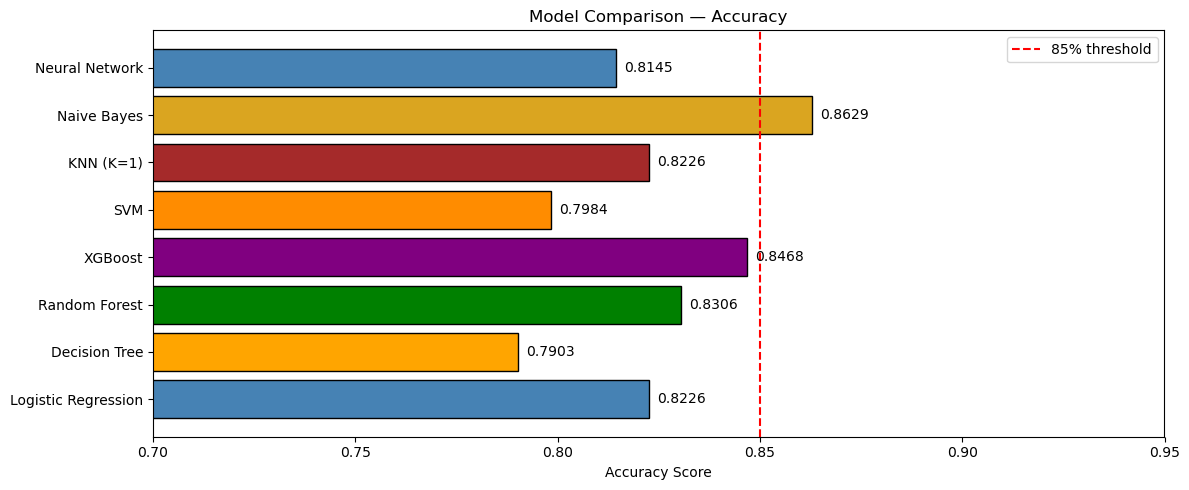

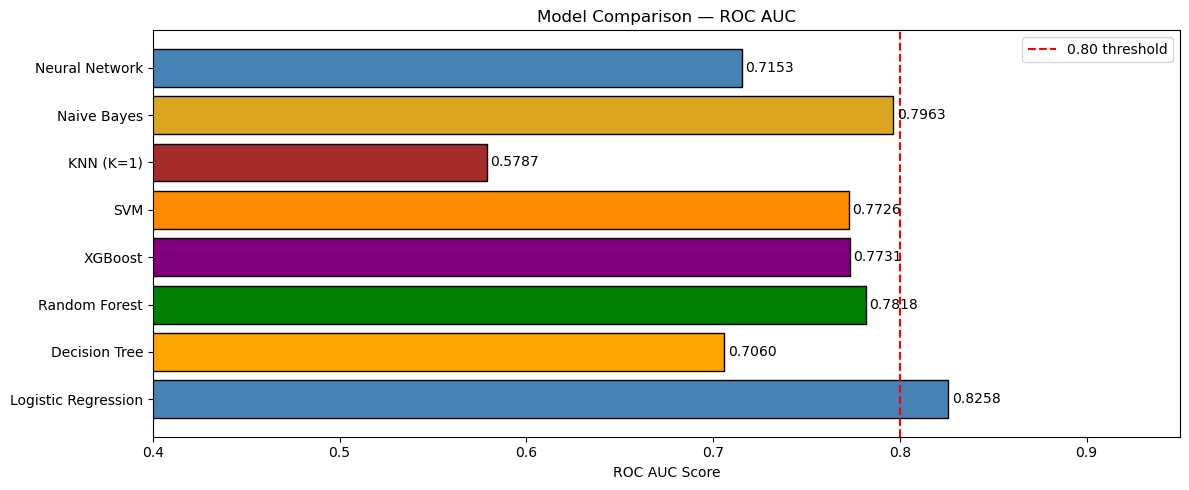

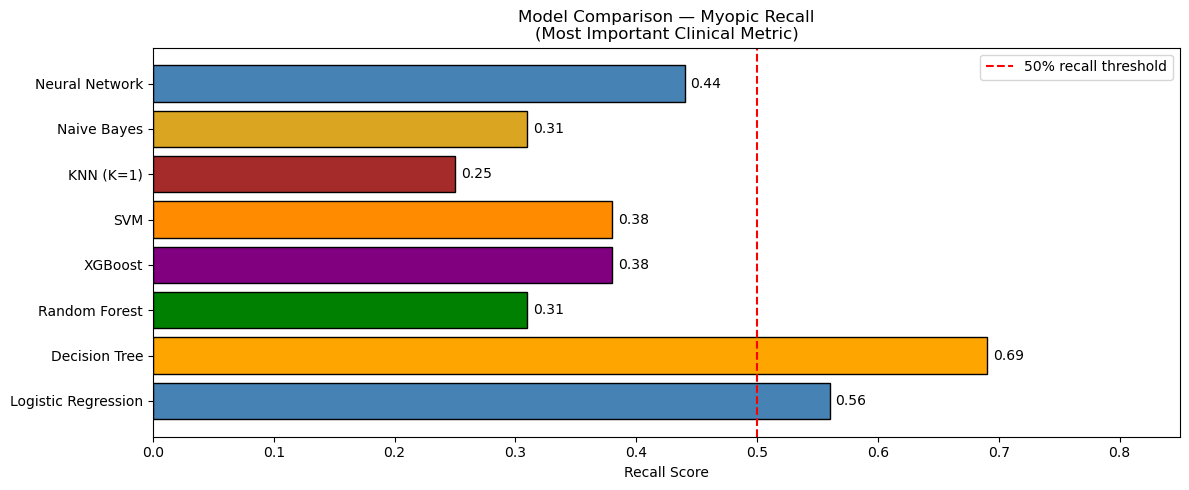

In [2]:
# ============================================
# VISUALIZATION 1 — ACCURACY COMPARISON
# ============================================
plt.figure(figsize=(12, 5))
colors = ['steelblue', 'orange', 'green', 'purple',
          'darkorange', 'brown', 'goldenrod', 'steelblue']
bars = plt.barh(results['Model'], results['Accuracy'],
                color=colors, edgecolor='black')
plt.axvline(x=0.85, color='red', linestyle='--',
            label='85% threshold')
plt.title("Model Comparison — Accuracy")
plt.xlabel("Accuracy Score")
plt.xlim(0.7, 0.95)
for bar, val in zip(bars, results['Accuracy']):
    plt.text(bar.get_width() + 0.002,
             bar.get_y() + bar.get_height()/2,
             f'{val:.4f}', va='center')
plt.legend()
plt.tight_layout()
plt.show()

# ============================================
# VISUALIZATION 2 — ROC AUC COMPARISON
# ============================================
plt.figure(figsize=(12, 5))
bars = plt.barh(results['Model'], results['ROC_AUC'],
                color=colors, edgecolor='black')
plt.axvline(x=0.80, color='red', linestyle='--',
            label='0.80 threshold')
plt.title("Model Comparison — ROC AUC")
plt.xlabel("ROC AUC Score")
plt.xlim(0.4, 0.95)
for bar, val in zip(bars, results['ROC_AUC']):
    plt.text(bar.get_width() + 0.002,
             bar.get_y() + bar.get_height()/2,
             f'{val:.4f}', va='center')
plt.legend()
plt.tight_layout()
plt.show()

# ============================================
# VISUALIZATION 3 — MYOPIC RECALL COMPARISON
# ============================================
plt.figure(figsize=(12, 5))
bars = plt.barh(results['Model'], results['Myopic_Recall'],
                color=colors, edgecolor='black')
plt.axvline(x=0.50, color='red', linestyle='--',
            label='50% recall threshold')
plt.title("Model Comparison — Myopic Recall\n(Most Important Clinical Metric)")
plt.xlabel("Recall Score")
plt.xlim(0, 0.85)
for bar, val in zip(bars, results['Myopic_Recall']):
    plt.text(bar.get_width() + 0.005,
             bar.get_y() + bar.get_height()/2,
             f'{val:.2f}', va='center')
plt.legend()
plt.tight_layout()
plt.show()

C:\Users\hp\AppData\Local\Temp\ipykernel_17240\3598670653.py:34: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\hp\AppData\Local\Temp\ipykernel_17240\3598670653.py:34: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


C:\Users\hp\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\hp\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


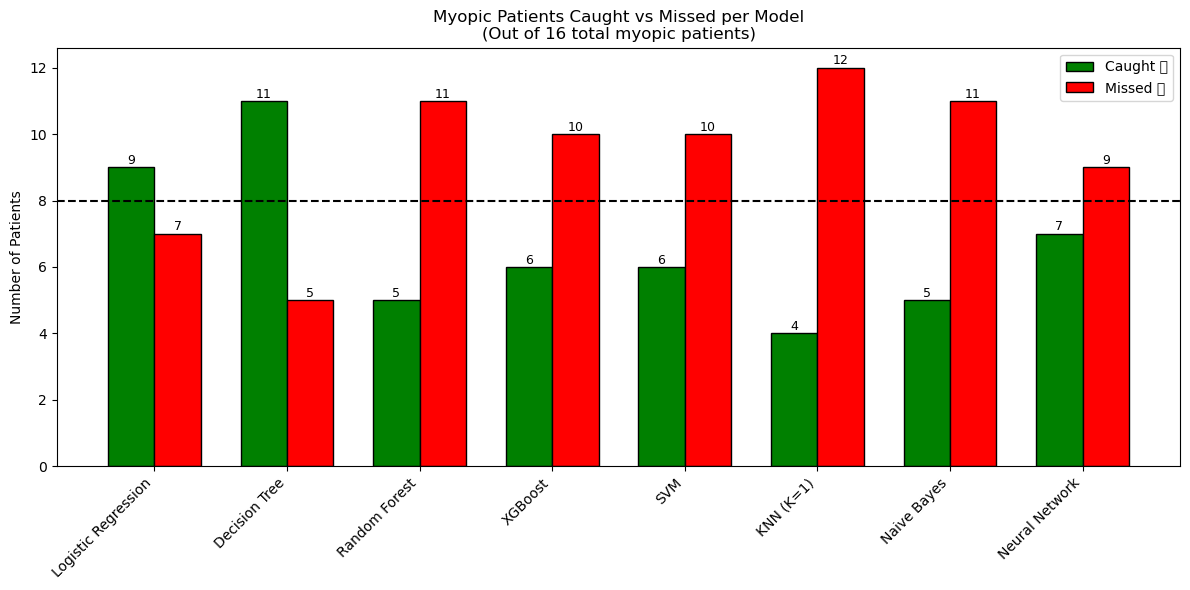

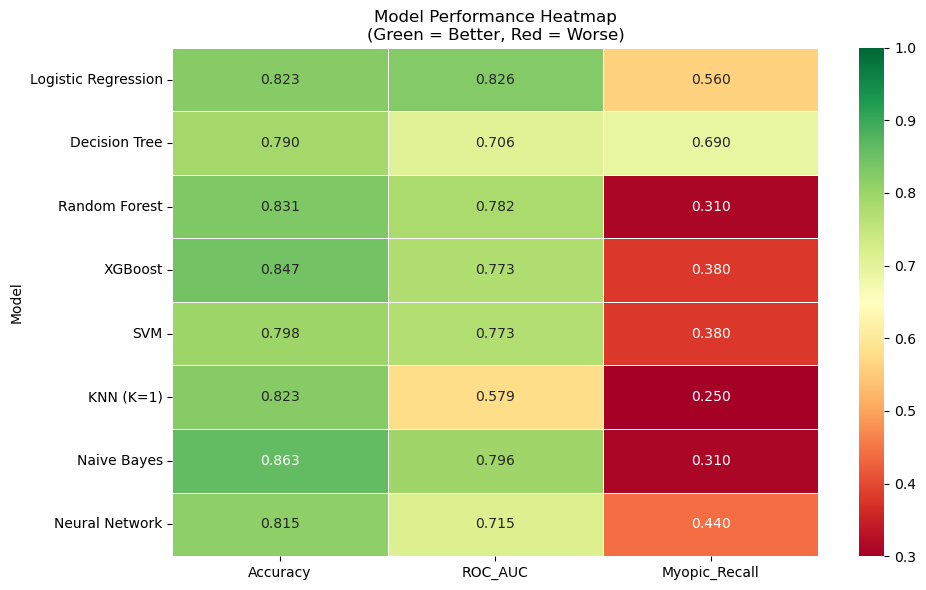

FINAL RANKINGS:

By Accuracy (highest = best):
              Model  Accuracy
        Naive Bayes    0.8629
            XGBoost    0.8468
      Random Forest    0.8306
Logistic Regression    0.8226
          KNN (K=1)    0.8226
     Neural Network    0.8145
                SVM    0.7984
      Decision Tree    0.7903

By ROC AUC (highest = best):
              Model  ROC_AUC
Logistic Regression   0.8258
        Naive Bayes   0.7963
      Random Forest   0.7818
            XGBoost   0.7731
                SVM   0.7726
     Neural Network   0.7153
      Decision Tree   0.7060
          KNN (K=1)   0.5787

By Myopic Recall (highest = best — most important clinically):
              Model  Myopic_Recall  Myopic_Caught  Myopic_Missed
      Decision Tree           0.69             11              5
Logistic Regression           0.56              9              7
     Neural Network           0.44              7              9
            XGBoost           0.38              6             10
   

In [3]:
# ============================================
# VISUALIZATION 4 — MYOPIC CAUGHT VS MISSED
# ============================================
fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(results['Model']))
width = 0.35

bars1 = ax.bar(x - width/2, results['Myopic_Caught'],
               width, label='Caught ✅', color='green',
               edgecolor='black')
bars2 = ax.bar(x + width/2, results['Myopic_Missed'],
               width, label='Missed ❌', color='red',
               edgecolor='black')

ax.set_title("Myopic Patients Caught vs Missed per Model\n(Out of 16 total myopic patients)")
ax.set_xticks(x)
ax.set_xticklabels(results['Model'], rotation=45, ha='right')
ax.set_ylabel("Number of Patients")
ax.legend()
ax.axhline(y=8, color='black', linestyle='--',
           label='50% line')

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.1,
            str(int(bar.get_height())),
            ha='center', fontsize=9)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.1,
            str(int(bar.get_height())),
            ha='center', fontsize=9)

plt.tight_layout()
plt.show()

# ============================================
# VISUALIZATION 5 — OVERALL HEATMAP
# ============================================
metrics_df = results.set_index('Model')[
    ['Accuracy', 'ROC_AUC', 'Myopic_Recall']]

plt.figure(figsize=(10, 6))
sns.heatmap(metrics_df,
            annot=True, fmt='.3f',
            cmap='RdYlGn',
            linewidths=0.5,
            vmin=0.3, vmax=1.0)
plt.title("Model Performance Heatmap\n(Green = Better, Red = Worse)")
plt.tight_layout()
plt.show()

# ============================================
# FINAL RANKINGS
# ============================================
print("FINAL RANKINGS:")
print("\nBy Accuracy (highest = best):")
print(results[['Model','Accuracy']].sort_values(
    'Accuracy', ascending=False).to_string(index=False))

print("\nBy ROC AUC (highest = best):")
print(results[['Model','ROC_AUC']].sort_values(
    'ROC_AUC', ascending=False).to_string(index=False))

print("\nBy Myopic Recall (highest = best — most important clinically):")
print(results[['Model','Myopic_Recall','Myopic_Caught','Myopic_Missed']].sort_values(
    'Myopic_Recall', ascending=False).to_string(index=False))

In [ ]:
# ============================================
# FINAL CONCLUSION
# ============================================
print("=" * 65)
print("FINAL CONCLUSION — MYOPIA PREDICTOR PROJECT")
print("=" * 65)

print("""
RESEARCH QUESTION:
"Which ML algorithm best identifies reliable predictors
of juvenile myopia?"

DATASET:
- 618 patients aged 5-9 years
- 15 clinical and lifestyle features
- 81 myopic (13.1%) vs 537 not myopic (86.9%)

─────────────────────────────────────────────────────────────
WINNER BY ACCURACY:     Naive Bayes     (86.29%)
WINNER BY ROC AUC:      Logistic Reg.   (0.8258)
WINNER BY RECALL:       Decision Tree   (69% — 11/16 caught)
─────────────────────────────────────────────────────────────

CLINICAL RECOMMENDATION:
Decision Tree is the best model for clinical screening
because it catches the most myopic children (11 out of 16)
— missing fewer patients than any other model.

In medical screening — missing a case is always more
dangerous than a false alarm.

─────────────────────────────────────────────────────────────
KEY PREDICTORS OF JUVENILE MYOPIA IDENTIFIED:
─────────────────────────────────────────────────────────────

1. SPHEQ (Spherical Equivalent)
   Most powerful predictor across ALL models
   Lower SPHEQ = higher myopia risk

2. SPORTHR (Sport Hours)
   Strongest modifiable protective factor
   More outdoor sport = lower myopia risk

3. DADMY (Father Myopic)
   Strongest genetic predictor
   Paternal myopia = higher child risk

4. AL (Axial Length)
   Key biological predictor
   Longer axial length = higher risk

5. MOMMY (Mother Myopic)
   Second genetic predictor
   Maternal myopia = higher child risk

6. ACD (Anterior Chamber Depth)
   Structural eye predictor
   Deeper chamber = higher risk

7. COMPHR (Computer Hours)
   Key environmental predictor (XGBoost finding)
   More screen time = higher risk

─────────────────────────────────────────────────────────────
CLINICAL IMPLICATIONS:
─────────────────────────────────────────────────────────────

Early screening should prioritise children who:
✅ Have low or negative spherical equivalent
✅ Have one or both parents with myopia
✅ Spend little time on outdoor activities
✅ Have longer than average axial length
✅ Spend significant time on computers

PREVENTIVE RECOMMENDATIONS:
✅ Increase outdoor activity (minimum 2 hours/day)
✅ Limit screen time especially computer use
✅ Regular screening for children of myopic parents
✅ Monitor SPHEQ closely in children approaching 0.00D

─────────────────────────────────────────────────────────────
LIMITATIONS:
─────────────────────────────────────────────────────────────
- Small dataset (618 patients)
- Significant class imbalance (13% myopic)
- Data from 1990-1995 (pre-smartphone era)
- Single geographic population
- Age range limited to 5-9 years
""")

print("=" * 65)
print("PROJECT COMPLETE!")
print("=" * 65)